# EDA · capa bronce — calidad de datos y decisiones de fuente

Notebook base del EDA. Responde a una pregunta distinta de la de sus continuaciones: no *qué
dicen los datos sobre el precio* (eso es el 03), ni *cómo funciona el sistema* (el 04 y el 05),
sino **si los datos que vamos a usar son los correctos y qué limitaciones tienen**.

Reconstruido el 28-ago-2026 con los nombres reales de columna y con todo lo aprendido en la
radiografía de la base. Corre sobre `bronze_unificado.parquet`, 58.319 horas.

## Los tres principios de la capa, que este notebook no rompe

1. **El bronce no imputa.** Ni outliers, ni deduplicación, ni relleno de huecos, ni
   Kelvin→Celsius. Eso es silver. Los `NaN` que se ven aquí son huecos reales.
2. **Tres granularidades, tres formas de unir, ninguna difunde valores.** `hourly` y `3h` unen
   exacto por `ts_utc`; `daily` aterriza sólo en la hora 00 local y deja 23 de 24 en `NaN` a
   propósito. Un 95,8 % de nulos en una tabla diaria **no es un hueco**, es 23/24.
3. **Prefijo por tabla**, para que dos columnas que miden cosas distintas en fuentes distintas
   no se confundan.

## Formato

Cada bloque va como **contexto → decisión → evidencia → consecuencia**. Una afirmación sin el
número que la respalda no entra. Ese formato es lo que hace citable el trabajo en la memoria.

## Índice

| Bloque | Contenido |
|---|---|
| **0** | Carga, integridad y panorama |
| **A.1** | D-02 · el gas de ENTSO-E no es el de ESIOS |
| **A.2** | D-03 · autoconsumo en la demanda |
| **A.3** | D-03 · autoconsumo en la solar |
| **A.4** | D-04 · columnas constantes |
| **A.5** | ¿La demanda residual prevista arrastra autoconsumo? |
| **B** | Perfil de nulos: qué es estructural y qué es un hueco |
| **C** | Distribuciones y outliers |
| **D** | Cobertura temporal y bordes de cambio de hora |
| **E** | Consistencia cruzada entre fuentes |
| **F** | Discontinuidades de ingesta (ERA5 y `entsoe_load`) |
| **G** | Cierre: hallazgos y qué hacer con cada uno |

---
## 0 · Carga, integridad y panorama

In [51]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

TZ = "Europe/Madrid"
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BRONZE_DIR = RAIZ / "data" / "bronze"

plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

HALLAZGOS = []

def anotar(codigo, titulo, estado, detalle):
    '''Registro único de hallazgos: alimenta la tabla de cierre del bloque G.'''
    HALLAZGOS.append({"código": codigo, "hallazgo": titulo,
                      "estado": estado, "consecuencia": detalle})
    print(f"[{codigo}] {estado}: {titulo}")

def pick(df, *cands):
    for c in cands:
        if c is not None and c in df.columns:
            return c
    return None

In [52]:
df = pd.read_parquet(BRONZE_DIR / "bronze_unificado.parquet")
df["ts_utc"] = pd.to_datetime(df["ts_utc"], utc=True)

# Integridad: una fila por hora. Si falla, alguna tabla está declarada con el grain
# equivocado y el merge la ha multiplicado -- todos los conteos de este notebook saldrían
# inflados por el mismo factor sin que ninguna correlación lo delate.
dup = df["ts_utc"].duplicated().sum()
assert dup == 0, (f"{dup:,} horas repetidas: {len(df):,} filas para "
                  f"{df['ts_utc'].nunique():,} horas (factor {len(df)/df['ts_utc'].nunique():.1f}).")

df["ts_local"] = df["ts_utc"].dt.tz_convert(TZ)
df["anio"] = df["ts_local"].dt.year
df["mes_p"] = df["ts_local"].dt.to_period("M")
df["date_local"] = df["ts_local"].dt.date
df["hora"] = df["ts_local"].dt.hour

print(f"{df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Rango: {df['ts_utc'].min()} -> {df['ts_utc'].max()}")

def origen(col):
    if col in ("ts_utc", "ts_local", "date_utc", "date_local", "hour_utc", "hour_local",
               "anio", "mes_p", "hora"):
        return "calendario"
    for p in ("calc_", "cap_disp_", "cap_inst_", "esios_gen_", "load_inter_",
              "commodities_", "forecast_", "era5_", "entsoe_"):
        if col.startswith(p):
            return p.rstrip("_")
    return "otro"

display(pd.Series([origen(c) for c in df.columns]).value_counts().rename("columnas").to_frame())

58,319 filas x 100 columnas
Rango: 2019-12-31 23:00:00+00:00 -> 2026-08-26 21:00:00+00:00


C:\Users\torgi\AppData\Local\Temp\ipykernel_26636\3176348101.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["mes_p"] = df["ts_local"].dt.to_period("M")


,columnas
cap_inst,18
otro,14
load_inter,13
entsoe,11
esios_gen,10
calendario,9
era5,9
cap_disp,6
forecast,4
commodities,3


---
## A.1 · D-02 — el gas de ENTSO-E y el de ESIOS no son intercambiables

**Contexto.** `entsoe_gas_mw` (categoría B04 de ENTSO-E) mezcla ciclo combinado y cogeneración.
ESIOS los separa: `ree_gccgas_mw` es CCGT puro y `ree_gotherthermal_mw` recoge cogeneración y
resto. Si la suma de ESIOS reproduce el B04, las dos fuentes son equivalentes.

**Decisión documentada (D-02).** Usar ESIOS con las dos columnas separadas: el CCGT marca el
precio marginal y la cogeneración es inelástica, así que mezclarlas pierde justo la información
que importa. `entsoe_gas_mw` se descarta del modelado y se conserva sólo para esta verificación.

**Por qué se comprueba en vez de citarla.** Una decisión heredada sin evidencia propia es una
cita a una conversación. Con evidencia, es un resultado.

Correlación entsoe_gas vs CCGT solo:  0.97876
Correlación entsoe_gas vs suma ESIOS: 0.99627

Diferencia media vs CCGT solo: 1,890.7 MW
Diferencia media vs la suma:   -374.2 MW


,entsoe_gas_mw,esios_gen_ree_gccgas_mw,esios_gen_ree_gotherthermal_mw,diferencia
anio,,,,
2020,7010.0,4416.0,3400.0,-806.0
2021,7035.0,4358.0,3235.0,-558.0
2022,8818.0,6963.0,2196.0,-341.0
2023,6209.0,4546.0,1920.0,-257.0
2024,4829.0,3314.0,1738.0,-222.0
2025,5950.0,4426.0,1701.0,-177.0
2026,5644.0,4498.0,1338.0,-192.0


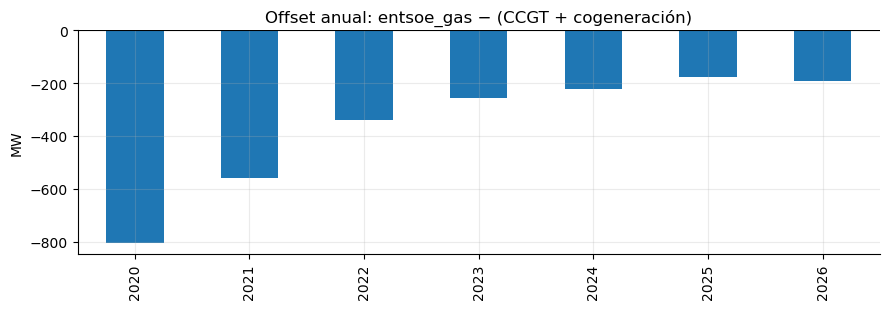

In [53]:
GAS_ENT = pick(df, "entsoe_gas_mw")
CCGT = pick(df, "esios_gen_ree_gccgas_mw", "esios_gen_ree_gccgt")
OTHER = pick(df, "esios_gen_ree_gotherthermal_mw", "esios_gen_ree_gotherthermal")

if not all([GAS_ENT, CCGT, OTHER]):
    print("OMITIDO -- faltan columnas:", {"entsoe": GAS_ENT, "ccgt": CCGT, "other": OTHER})
else:
    d = df[["anio", GAS_ENT, CCGT, OTHER]].dropna().copy()
    d["suma_esios"] = d[CCGT] + d[OTHER]

    print(f"Correlación entsoe_gas vs CCGT solo:  {d[GAS_ENT].corr(d[CCGT]):.5f}")
    print(f"Correlación entsoe_gas vs suma ESIOS: {d[GAS_ENT].corr(d['suma_esios']):.5f}")
    print(f"\nDiferencia media vs CCGT solo: {(d[GAS_ENT] - d[CCGT]).mean():,.1f} MW")
    print(f"Diferencia media vs la suma:   {(d[GAS_ENT] - d['suma_esios']).mean():,.1f} MW")

    anual = d.groupby("anio")[[GAS_ENT, CCGT, OTHER]].mean().round(0)
    anual["diferencia"] = (d.groupby("anio")[GAS_ENT].mean()
                           - d.groupby("anio")["suma_esios"].mean()).round(0)
    display(anual)

    ax = anual["diferencia"].plot(kind="bar", figsize=(9, 3.2),
        title="Offset anual: entsoe_gas − (CCGT + cogeneración)")
    ax.set_ylabel("MW"); ax.set_xlabel(""); ax.axhline(0, color="black", lw=0.8)
    plt.tight_layout(); plt.show()

**Consecuencia.** Si la correlación contra la suma es claramente mayor que contra el CCGT
solo, queda confirmado que el B04 es la suma, no el ciclo combinado puro. Y si el offset cambia
año a año, **no se puede usar una fuente en train y otra en test**: se introduciría un sesgo que
varía con el tiempo, que es la peor clase de sesgo porque imita una señal.

*A reconciliar en la redacción:* D-02 citaba un offset cayendo de ~2.600 MW (2020) a ~1.150 MW
(2026). La corrida propia da cifras distintas según se mida contra el CCGT o contra la suma. La
dirección y el orden de magnitud de la caída coinciden; el valor exacto, no. Conviene decir en
la memoria contra qué referencia se mide cada número antes de darlos por equivalentes.

In [54]:
if all([GAS_ENT, CCGT, OTHER]):
    anotar("D-02", "El B04 de ENTSO-E mezcla CCGT y cogeneración, con offset no estable",
           "confirmado",
           "Usar ESIOS con las dos columnas separadas. entsoe_gas_mw fuera del modelado.")

[D-02] confirmado: El B04 de ENTSO-E mezcla CCGT y cogeneración, con offset no estable


---
## A.2 · D-03 — el autoconsumo entra en la demanda desde diciembre de 2025

**Contexto.** `ree_load` y `entsoe_load` medían lo mismo hasta que REE incorporó una estimación
de autoconsumo a su serie. La diferencia entre ambas (`calc_autoconsumo_mw`, ya calculada en el
bronce) no es ruido de medida: es esa estimación.

**Decisión documentada (D-03).** Usar `entsoe_load` para modelar. `ree_load` se conserva porque
su diferencia estima el autoconsumo peninsular, no porque sea una segunda candidata a "demanda
real".

**Nota de método.** El perfil horario se calcula **sólo sobre el período donde el fenómeno
existe** (dic-2025 en adelante). Promediar todo el histórico mezcla 71 meses de ruido de fondo
con los meses en que el efecto es real y aplana el patrón.

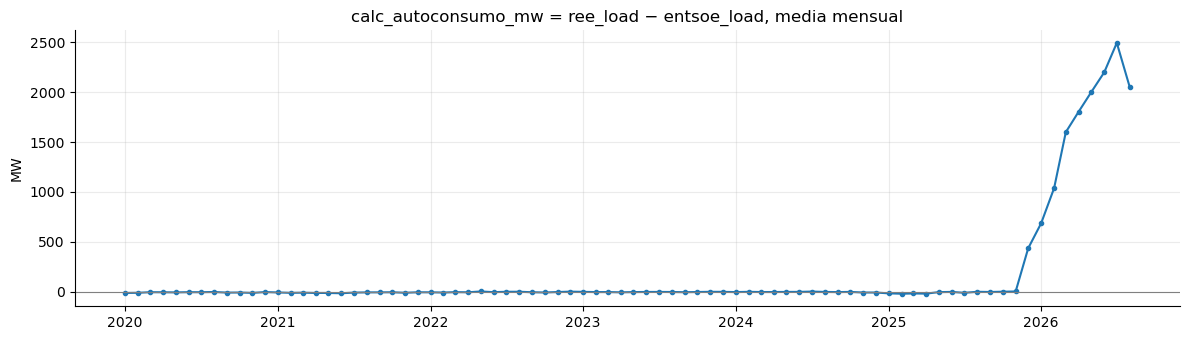

Primer mes por encima del umbral (49 MW): 2025-12
Valor: 434.7 MW | último del histórico: 2,051.0 MW


,MW
mes_p,
2025-09,-3.9
2025-10,-1.0
2025-11,1.3
2025-12,434.7
2026-01,685.7
2026-02,1038.1
2026-03,1599.7
2026-04,1806.9
2026-05,2002.3


In [55]:
AUTO = pick(df, "calc_autoconsumo_mw")
if AUTO is None:
    print("OMITIDO -- falta calc_autoconsumo_mw")
else:
    por_mes = df.groupby("mes_p")[AUTO].mean()
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(por_mes.index.to_timestamp(), por_mes.values, marker="o", ms=3)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_ylabel("MW"); ax.set_title("calc_autoconsumo_mw = ree_load − entsoe_load, media mensual")
    plt.tight_layout(); plt.show()

    # Detección automática del mes de quiebre: primer mes que supera 10x la desviación
    # del período previo. Así el corte sale del dato, no de una fecha escrita a mano.
    base = por_mes[por_mes.index < "2025-06"]
    umbral = base.std() * 10
    quiebre = por_mes[por_mes.abs() > max(umbral, 50)]
    if len(quiebre):
        print(f"Primer mes por encima del umbral ({umbral:.0f} MW): {quiebre.index[0]}")
        print(f"Valor: {quiebre.iloc[0]:,.1f} MW | último del histórico: {por_mes.iloc[-1]:,.1f} MW")
    display(por_mes.tail(12).round(1).rename("MW").to_frame())

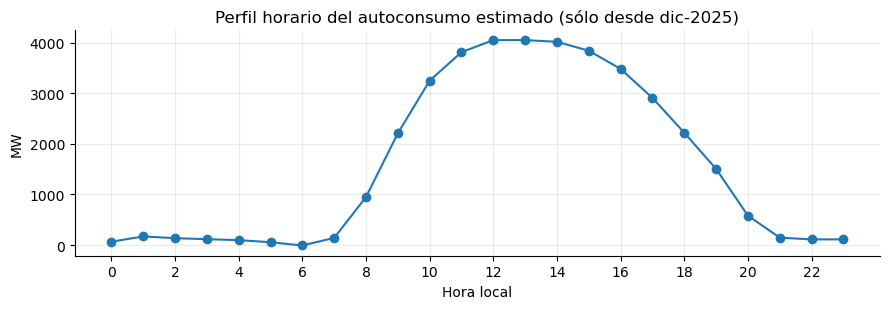

Pico a las 13h (4,054 MW), mínimo a las 6h (-9 MW).
Una campana con pico a mediodía es la firma del autoconsumo fotovoltaico. Si fuera ruido de medida, sería plano.


In [56]:
if AUTO:
    post = df[df["ts_local"] >= "2025-12-01"]
    if len(post):
        perfil = post.groupby("hora")[AUTO].mean()
        ax = perfil.plot(marker="o", figsize=(9, 3.2),
            title="Perfil horario del autoconsumo estimado (sólo desde dic-2025)")
        ax.set_xlabel("Hora local"); ax.set_ylabel("MW"); ax.set_xticks(range(0, 24, 2))
        plt.tight_layout(); plt.show()
        print(f"Pico a las {perfil.idxmax()}h ({perfil.max():,.0f} MW), "
              f"mínimo a las {perfil.idxmin()}h ({perfil.min():,.0f} MW).")
        print("Una campana con pico a mediodía es la firma del autoconsumo fotovoltaico. "
              "Si fuera ruido de medida, sería plano.")

## A.3 · D-03 — el mismo autoconsumo, por el lado de la generación

**Contexto.** El autoconsumo entra por los dos lados del balance. Si `ree_gsolar_mw` rompe **el
mismo mes y con magnitud similar** que la demanda, es la confirmación cruzada de que se trata
del mismo fenómeno y no de dos problemas distintos.

**Importante para no fabricar un problema inexistente:** la comparación correcta es contra
`calc_solar_fv_mw` (la FV ya limpia de termosolar), no contra `entsoe_solar_mw` directo. Esta
última agrega FV y termosolar, y restarla sin quitar la termosolar contamina la diferencia con
la estacionalidad de ésta — fuerte en verano, casi nula en invierno.

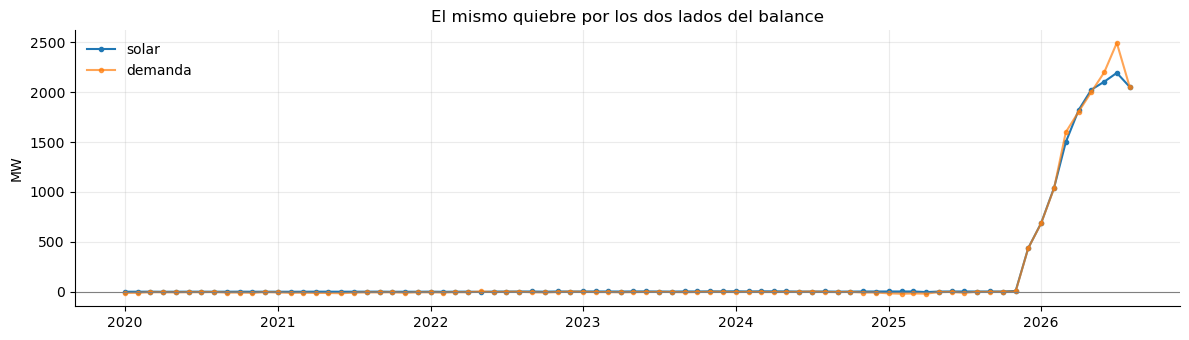

,MW
mes_p,
2025-09,1.1
2025-10,1.0
2025-11,6.7
2025-12,435.7
2026-01,687.5
2026-02,1043.5
2026-03,1500.2
2026-04,1824.1
2026-05,2025.5


Correlación entre ambas series mensuales: 0.9984
Cerca de 1 confirma que es el MISMO autoconsumo entrando por demanda y por generación, no dos fenómenos independientes.
[D-03] confirmado: Autoconsumo dentro de las series de ESIOS desde dic-2025


In [57]:
SOL_REE = pick(df, "esios_gen_ree_gsolar_mw")
SOL_FV = pick(df, "calc_solar_fv_mw")

if not (SOL_REE and SOL_FV):
    print("OMITIDO --", {"ree_gsolar": SOL_REE, "calc_solar_fv": SOL_FV})
else:
    d = df[["mes_p", SOL_REE, SOL_FV]].dropna()
    dif_solar = (d[SOL_REE] - d[SOL_FV]).groupby(d["mes_p"]).mean()

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(dif_solar.index.to_timestamp(), dif_solar.values, marker="o", ms=3, label="solar")
    if AUTO:
        ax.plot(por_mes.index.to_timestamp(), por_mes.values, marker="o", ms=3,
                alpha=0.7, label="demanda")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_ylabel("MW"); ax.set_title("El mismo quiebre por los dos lados del balance")
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()
    display(dif_solar.tail(12).round(1).rename("MW").to_frame())

    if AUTO:
        comun = dif_solar.index.intersection(por_mes.index)
        print(f"Correlación entre ambas series mensuales: "
              f"{dif_solar[comun].corr(por_mes[comun]):.4f}")
        print("Cerca de 1 confirma que es el MISMO autoconsumo entrando por demanda y por "
              "generación, no dos fenómenos independientes.")
        anotar("D-03", "Autoconsumo dentro de las series de ESIOS desde dic-2025", "confirmado",
               "No usar ree_load ni ree_gsolar_mw directos. FV limpia = calc_solar_fv_mw.")

---
## A.4 · D-04 — columnas constantes

**Contexto.** La auditoría de calidad encontró columnas de capacidad con varianza cero en más de
seis años, y un indicador sospechosamente congelado.

**Decisión documentada (D-04).** Las constantes no se borran de la base — el dato es correcto,
España no conectó nucleares ni ciclos combinados nuevos desde 2020 — pero **se excluyen del
conjunto de features**: una varianza cero no puede explicar nada en un modelo.

In [58]:
cap = [c for c in df.columns if c.startswith(("cap_inst_", "cap_disp_"))]
if not cap:
    print("OMITIDO -- no hay columnas de capacidad")
else:
    resumen = pd.DataFrame({"nunique": df[cap].nunique(), "std": df[cap].std(),
                            "media": df[cap].mean()}).sort_values("nunique")
    display(resumen.round(2))

    constantes = resumen[resumen["nunique"] <= 1].index.tolist()
    print(f"\n{len(constantes)} columnas constantes: {constantes}")
    if constantes:
        anotar("D-04", f"{len(constantes)} columnas de capacidad con varianza cero", "confirmado",
               "Correctas pero inútiles como feature. Se traen, se excluyen del modelado.")

,nunique,std,media
cap_inst_pump_mw,1,0.00,3331.40
cap_disp_fuel_mw,1,0.00,7.90
cap_inst_autoconsume_battery_mw,1,0.00,5.00
cap_inst_nuclear_mw,1,0.00,7117.29
cap_inst_fuel_mw,1,0.00,7.95
cap_inst_ccgt_mw,1,0.00,24561.85
cap_inst_waste_renewable_mw,2,4.73,129.54
cap_inst_waste_nonrenewable_mw,8,9.90,391.86
cap_inst_battery_hybrid_mw,8,66.61,44.47
cap_inst_coal_mw,11,2319.05,3552.63



6 columnas constantes: ['cap_inst_pump_mw', 'cap_disp_fuel_mw', 'cap_inst_autoconsume_battery_mw', 'cap_inst_nuclear_mw', 'cap_inst_fuel_mw', 'cap_inst_ccgt_mw']
[D-04] confirmado: 6 columnas de capacidad con varianza cero


**Validación cruzada de D-03 por una vía independiente.** `cap_inst_autoconsume_solar_pv_mw`
no interviene en la resta de series horarias de A.2/A.3. Si crece de forma sostenida, respalda
la misma historia desde una tabla distinta — que es lo que convierte una hipótesis en un
resultado.

,min,max
anio,,
2020,25.58,456.96
2021,481.68,752.18
2022,800.05,1700.35
2023,1991.19,3719.32
2024,4011.27,6433.56
2025,6696.74,8472.22
2026,8560.49,9125.05


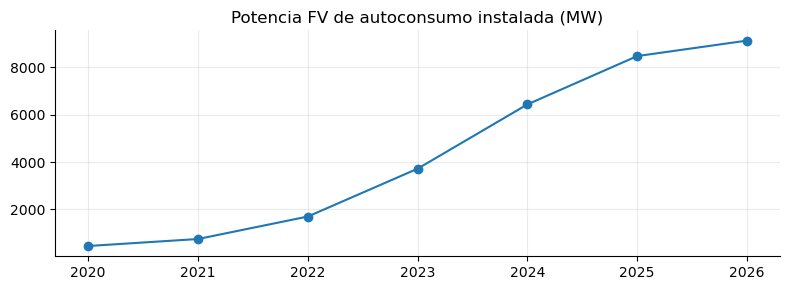

Crece de 26 a 9,125 MW. Coherente con la estimación de autoconsumo de A.2/A.3, medida por otro camino.


In [59]:
AUTO_CAP = pick(df, "cap_inst_autoconsume_solar_pv_mw")
if AUTO_CAP:
    ev = df.groupby("anio")[AUTO_CAP].agg(["min", "max"]).dropna()
    display(ev.round(2))
    ax = ev["max"].plot(marker="o", figsize=(8, 3),
        title="Potencia FV de autoconsumo instalada (MW)")
    ax.set_xlabel(""); plt.tight_layout(); plt.show()
    print(f"Crece de {ev['min'].iloc[0]:,.0f} a {ev['max'].iloc[-1]:,.0f} MW. Coherente con la "
          f"estimación de autoconsumo de A.2/A.3, medida por otro camino.")

---
## A.5 · ¿`demanda_residual_prev_mw` también arrastra autoconsumo?

**Contexto.** El maestro ya excluye esta columna, pero por otro motivo: se revisa 10-14 días
después de publicada. `demanda_mercado_prev_mw` está documentada como "sin autoconsumo" y sirve
de vara limpia. Si la residual tuviera el mismo quiebre de dic-2025, habría un segundo motivo,
independiente del primero, para mantenerla fuera.

**Consecuencia esperada.** Si la diferencia deriva suavemente sin salto, lo que se observa es la
resta de renovables que "residual" implica conceptualmente, creciendo con la penetración
renovable — no contaminación. Un bloque que cierra en negativo también es un resultado.

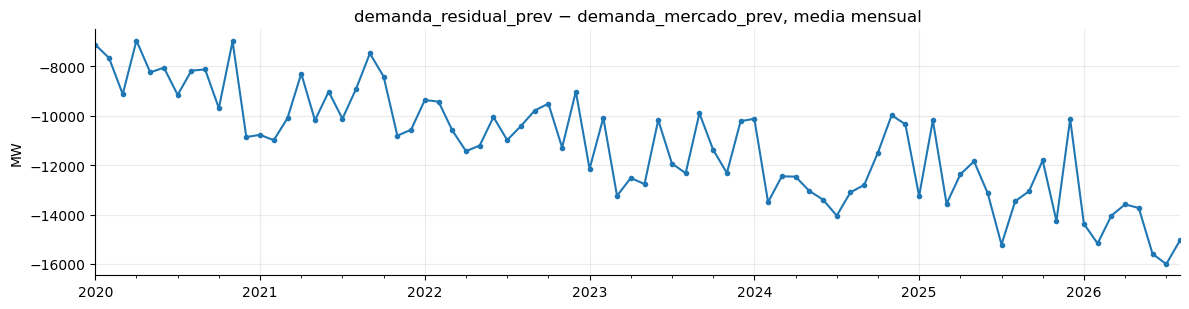

,MW
mes_p,
2025-06,-13143.0
2025-07,-15215.0
2025-08,-13454.0
2025-09,-13059.0
2025-10,-11806.0
2025-11,-14260.0
2025-12,-10128.0
2026-01,-14372.0
2026-02,-15171.0


Deriva suave = resta de renovables. Salto en dic-2025 = contaminación de autoconsumo.


In [60]:
RES = pick(df, "forecast_demanda_residual_prev_mw")
MERC = pick(df, "forecast_demanda_mercado_prev_mw", "forecast_demanda_prev_mw")

if not (RES and MERC):
    print("OMITIDO -- el bronce sólo trae 4 columnas de esios_forecast_da de las 14 que tiene.")
    print("   Para cerrar A.5 hay que ampliar la lista en bronze_config.py:",
          {"residual": RES, "mercado": MERC})
else:
    d = df[["mes_p", RES, MERC]].dropna()
    dif = (d[RES] - d[MERC]).groupby(d["mes_p"]).mean()
    ax = dif.plot(figsize=(12, 3.2), marker="o", ms=3,
        title="demanda_residual_prev − demanda_mercado_prev, media mensual")
    ax.set_ylabel("MW"); ax.set_xlabel("")
    plt.tight_layout(); plt.show()
    display(dif.tail(15).round(0).rename("MW").to_frame())
    print("Deriva suave = resta de renovables. Salto en dic-2025 = contaminación de autoconsumo.")

---
## B · Perfil de nulos: qué es estructural y qué es un hueco

**Contexto.** El mapa de nulos es la figura que más se malinterpreta de un EDA. Aquí hay tres
granularidades conviviendo, y dos de ellas producen nulos **por diseño**:

- tablas `daily` → el valor aterriza sólo en la hora 00 local: **23 de 24 en NaN, o sea 95,8 %**
- `era5` (3h) → una lectura cada tres horas: **~66,7 %**
- categorías recientes (baterías desde 2025, híbridos desde 2023) → nulos al principio del
  histórico

Nada de eso es un problema de calidad. Decirlo así en la memoria evita que un lector — o un
tribunal — lea el mapa de calor como una base agujereada.

In [61]:
nulos = df.isna().mean().mul(100).round(2).sort_values(ascending=False).rename("pct").to_frame()
nulos = nulos[nulos["pct"] > 0]
nulos["origen"] = [origen(c) for c in nulos.index]

def explicacion(row):
    p = row["pct"]
    if row["origen"] in ("cap_inst", "cap_disp", "commodities"):
        return "estructural: tabla diaria (23/24)" if 90 < p < 97 else "categoría reciente"
    if row["origen"] == "era5":
        return "estructural: 3h" if p < 67.1 else "3h + hueco genuino"
    if p < 5:
        return "hueco menor"
    return "revisar"

nulos["lectura"] = nulos.apply(explicacion, axis=1)
display(nulos.head(45))

,pct,origen,lectura
cap_inst_battery_hybrid_mw,98.34,cap_inst,categoría reciente
cap_inst_wind_hybrid_mw,98.28,cap_inst,categoría reciente
cap_inst_solar_pv_hybrid_mw,97.97,cap_inst,categoría reciente
cap_inst_autoconsume_battery_mw,97.92,cap_inst,categoría reciente
commodities_co2_eua_dec,97.09,commodities,categoría reciente
commodities_gas_ttf_m1,97.08,commodities,categoría reciente
cap_disp_nuclear_mw,95.83,cap_disp,estructural: tabla diaria (23/24)
cap_disp_hydro_mw,95.83,cap_disp,estructural: tabla diaria (23/24)
cap_inst_waste_nonrenewable_mw,95.83,cap_inst,estructural: tabla diaria (23/24)
cap_inst_hydro_mw,95.83,cap_inst,estructural: tabla diaria (23/24)


### B.1 · Hallazgo — convención asimétrica NULL/0 en el bombeo

**Contexto.** `entsoe_pumping_gen_mw` (turbinación) tiene muchos nulos; `entsoe_pumping_cons_mw`
(bombeo) prácticamente ninguno. Dos columnas de la misma tabla, midiendo el mismo fenómeno por
sus dos caras.

**La pregunta:** ¿es la misma convención de "ausencia" en las dos, o una usa `NULL` y la otra
`0` para decir "no ocurrió"?

In [62]:
PG = pick(df, "entsoe_pumping_gen_mw")
PC = pick(df, "entsoe_pumping_cons_mw")

if not (PG and PC):
    print("OMITIDO --", {"gen": PG, "cons": PC})
else:
    print(f"{PG}:  {df[PG].isna().mean()*100:.2f}% nulos · "
          f"{(df[PG] == 0).mean()*100:.2f}% ceros exactos")
    print(f"{PC}: {df[PC].isna().mean()*100:.2f}% nulos · "
          f"{(df[PC] == 0).mean()*100:.2f}% ceros exactos")

    gen_nulo_cons_dato = (df[PG].isna() & df[PC].notna()).sum()
    print(f"\nFilas con gen NULO y cons CON DATO: {gen_nulo_cons_dato:,}")
    print(f"Eso es el {gen_nulo_cons_dato / max(df[PG].isna().sum(), 1) * 100:.1f}% "
          f"de todos los nulos de gen.")

    anotar("B.1", "pumping_gen usa NULL y pumping_cons usa 0 para 'no ocurrió'", "confirmado",
           "En el maestro: fillna(0) sobre pumping_gen_mw ANTES de agregar. Sin eso, la media "
           "diaria se calcula sólo sobre las horas con turbinación e infla el resultado.")

entsoe_pumping_gen_mw:  43.85% nulos · 5.58% ceros exactos
entsoe_pumping_cons_mw: 0.06% nulos · 23.18% ceros exactos

Filas con gen NULO y cons CON DATO: 25,535
Eso es el 99.9% de todos los nulos de gen.
[B.1] confirmado: pumping_gen usa NULL y pumping_cons usa 0 para 'no ocurrió'


**Consecuencia, y es la que toca directamente al dataset de modelado.** Si `pumping_gen_mw`
se agrega con `.agg(["mean","min","max"])` sin `fillna(0)` previo, pandas **ignora los NaN en
lugar de contarlos como cero**: la media diaria sale calculada sólo sobre las horas con
turbinación real, no sobre el día completo. Eso infla la media y esconde el mínimo, que debería
ser 0 casi todos los días.

El bronce ya aplica el criterio correcto en `calc_hydro_dispatch_mw` (`.fillna(0)` explícito
antes de sumar). Hay que aplicar el mismo en `_features_lag_reales` del maestro:

```python
h["pumping_gen_mw"] = h["pumping_gen_mw"].fillna(0)   # NaN aquí = "no hubo turbinación"
```

Sólo sobre esa columna. Sobre cualquier otra sería incorrecto: ahí un `NaN` sí significa "no se
sabe".

### B.2 · Hallazgo — `era5_wind_gust10_mean` con nulos de más

**Contexto.** Sobre el patrón estructural de ERA5 (una lectura cada 3 h), la ráfaga tiene algo
más de nulos que el resto de variables climáticas. La hipótesis natural — que "ráfaga cercana a
cero" se guarde como nulo — se puede probar y descartar.

In [63]:
era5 = [c for c in df.columns if c.startswith("era5_")]
GUST = pick(df, "era5_wind_gust10_mean")
W10 = pick(df, "era5_wind10_mean")

if not (GUST and W10):
    print("OMITIDO --", {"gust": GUST, "wind10": W10})
else:
    otras = [c for c in era5 if c != GUST]
    estructural = df[otras].isna().mean().mul(100).min()
    print(f"Nulos estructurales (3h): {estructural:.2f}%")
    print(f"Nulos de wind_gust10:     {df[GUST].isna().mean()*100:.2f}%")
    print(f"Genuinos adicionales:     {df[GUST].isna().mean()*100 - estructural:.2f} pp")

    print(f"\nMínimo real de la ráfaga: {df[GUST].min():.3f} m/s · "
          f"ceros exactos: {(df[GUST] == 0).sum()}")
    con_dato = df.loc[df[GUST].notna() & df[W10].notna(), W10]
    sin_dato = df.loc[df[GUST].isna() & df[W10].notna(), W10]
    print(f"wind10 medio con ráfaga:  {con_dato.mean():.3f} m/s")
    print(f"wind10 medio sin ráfaga:  {sin_dato.mean():.3f} m/s")
    print("\nSi el mínimo no es cero y el viento medio es similar en ambos grupos, la "
          "hipótesis de censura por viento bajo queda DESCARTADA. Ver bloque F para la causa.")

Nulos estructurales (3h): 66.94%
Nulos de wind_gust10:     67.35%
Genuinos adicionales:     0.41 pp

Mínimo real de la ráfaga: 2.774 m/s · ceros exactos: 0
wind10 medio con ráfaga:  3.864 m/s
wind10 medio sin ráfaga:  3.558 m/s

Si el mínimo no es cero y el viento medio es similar en ambos grupos, la hipótesis de censura por viento bajo queda DESCARTADA. Ver bloque F para la causa.


**Nota para silver que conviene no perder.** Por su naturaleza de variable de pico,
`wind_gust10_mean` y `tp_mean` **no deberían interpolarse igual** que `t2m_mean` o
`wind10_mean`. Interpolar linealmente entre dos lecturas separadas 3 h subestima
sistemáticamente los eventos extremos ocurridos en el hueco — que son justamente los que mueven
el precio. Evaluar empíricamente contra el modelo, no decidirlo a priori.

---
## C · Distribuciones y outliers

**Nota de método sobre el IQR.** Varias columnas van a aparecer con muchísimos "outliers" sin
que haya nada sucio: son series con **cambio de régimen** (el carbón cerrado desde 2021, las
baterías como categoría desde 2025, el autoconsumo con su quiebre de dic-2025) o casi constantes
(una NTC con Q1=Q3 tiene IQR cero, y entonces *cualquier* valor distinto se marca como atípico).

El método compara todo el histórico junto: frente a un cambio estructural real, marca outliers
mecánicamente. Eso no es calidad de dato, es la aritmética del método.

In [64]:
num = df.select_dtypes(include=[np.number]).columns.drop(["anio", "hora"], errors="ignore")
display(df[num].describe(percentiles=[.01, .5, .99]).T.round(2))

,count,mean,std,min,1%,50%,99%,max
hour_utc,58319.0,11.50,6.92,0.00,0.00,11.00,23.00,23.00
hour_local,58319.0,11.50,6.92,0.00,0.00,12.00,23.00,23.00
entsoe_solar_mw,58283.0,4474.59,5969.73,0.00,4.00,711.00,22078.36,29620.00
entsoe_wind_mw,58283.0,6546.13,3887.99,181.00,772.00,5802.00,16858.18,20718.00
entsoe_hydro_run_river_mw,58283.0,954.88,349.05,253.00,337.00,953.00,1752.00,1994.00
...,...,...,...,...,...,...,...,...
era5_tp_mean,19279.0,0.07,0.10,0.00,0.00,0.03,0.45,1.30
era5_msl_mean,19279.0,101764.57,591.08,99126.55,100124.24,101729.70,103230.98,103785.93
calc_solar_fv_mw,58283.0,3981.38,5580.67,0.00,0.00,275.00,20826.83,28203.08
calc_hydro_dispatch_mw,58283.0,2922.41,2077.77,141.00,312.00,2441.00,8648.18,11045.00


In [65]:
q1, q3 = df[num].quantile(0.25), df[num].quantile(0.75)
iqr = q3 - q1
fuera = ((df[num] < (q1 - 1.5 * iqr)) | (df[num] > (q3 + 1.5 * iqr))).sum()
display(fuera[fuera > 0].sort_values(ascending=False).head(15).rename("outliers IQR").to_frame())
print("Leer con la nota de arriba: casi todos son cambios de régimen, no datos sucios.")

,outliers IQR
calc_autoconsumo_mw,7237
load_inter_ree_ntc_impma,6213
spot_it_nord_entsoe,4662
spot_fr_entsoe,4386
spot_ch_entsoe,4335
spot_be_entsoe,4050
spot_de_lu_entsoe,3930
spot_cz_entsoe,3870
spot_at_entsoe,3845
spot_nl_entsoe,3815


Leer con la nota de arriba: casi todos son cambios de régimen, no datos sucios.


### C.1 · Hallazgo — `entsoe_load` con ceros espurios

**Contexto.** Una demanda peninsular de 0 MW es físicamente imposible: nunca baja de varios
miles. Si el mínimo de la columna es 0, hay un corte de ingesta.

**Además explica un outlier aguas abajo:** `calc_autoconsumo_mw` se calcula restando contra esta
columna, así que un cero espurio se propaga a la derivada convertido en un valor enorme.

In [66]:
ENT_LOAD = pick(df, "load_inter_entsoe_load")
REE_LOAD = pick(df, "load_inter_ree_load")

if not ENT_LOAD:
    print("OMITIDO -- falta load_inter_entsoe_load")
else:
    ceros = df[df[ENT_LOAD] == 0]
    print(f"Filas con entsoe_load == 0: {len(ceros)} de {len(df):,} "
          f"({len(ceros)/len(df)*100:.4f}%)")
    if len(ceros):
        cols = ["ts_utc"] + [c for c in (REE_LOAD, AUTO) if c]
        display(ceros[cols + [ENT_LOAD]])
        print(f"\nMáximo de calc_autoconsumo_mw: {df[AUTO].max():,.0f} MW" if AUTO else "")
        print("Contra un rango confirmado de ~2.500 MW en A.2: el error se propaga a la derivada.")
        anotar("C.1", f"{len(ceros)} horas de entsoe_load en cero espurio", "confirmado",
               "Fallo de ingesta documentado en pipeline_log. Reparar con entsoe_load_inter."
               " No usar calc_autoconsumo_mw sin tratar esas horas.")

Filas con entsoe_load == 0: 9 de 58,319 (0.0154%)


,ts_utc,load_inter_ree_load,calc_autoconsumo_mw,load_inter_entsoe_load
54420,2026-03-17 11:00:00+00:00,33597.00,33597.00,0.0
56952,2026-06-30 23:00:00+00:00,28431.58,28431.58,0.0
56953,2026-07-01 00:00:00+00:00,26949.25,26949.25,0.0
56954,2026-07-01 01:00:00+00:00,26104.08,26104.08,0.0
56955,2026-07-01 02:00:00+00:00,25733.67,25733.67,0.0
56956,2026-07-01 03:00:00+00:00,25948.00,25948.00,0.0
56957,2026-07-01 04:00:00+00:00,27779.42,27779.42,0.0
56958,2026-07-01 05:00:00+00:00,30225.83,30225.83,0.0
56959,2026-07-01 06:00:00+00:00,33548.17,33548.17,0.0



Máximo de calc_autoconsumo_mw: 33,597 MW
Contra un rango confirmado de ~2.500 MW en A.2: el error se propaga a la derivada.
[C.1] confirmado: 9 horas de entsoe_load en cero espurio


**Evidencia de la causa, que ya no es una hipótesis.** El registro `pipeline_log` de la base
muestra que el pipeline `entsoe_daily` del 29 y del 30 de junio de 2026 quedó en estado
`parcial` y **reintentó 72 veces cada día**, siempre con 0 insert y 0 update. El primer intento
sí insertó 24 filas y se marcó parcial: metió los registros con ceros, y ninguno de los 72
reintentos consiguió corregirlos.

Eso convierte "pinta a corte de ingesta" en un fallo documentado con hora. Y sugiere el arreglo
correcto: `entsoe_load_inter.actual_load_mw` es un segundo camino para el mismo dato — si tiene
valor bueno en esas horas, **reparar es mejor que imputar**.

### C.2 · Hallazgo — generación solar y termosolar negativa

**Contexto.** Valores negativos en generación parecen un error de signo. Antes de corregir nada,
conviene preguntarse si hay una explicación física: las plantas termosolares consumen de noche
para mover seguidores y bombear sales fundidas.

**Cómo se distingue un error de un fenómeno real:** por *cuándo* ocurre. Un error de signo se
reparte al azar; el consumo auxiliar se concentra en horas nocturnas.

esios_gen_ree_gsolter_mw: 6 filas negativas, mínimo -126.58 MW, 17% en horas nocturnas
esios_gen_ree_gsolar_mw: 67 filas negativas, mínimo -62.83 MW, 100% en horas nocturnas


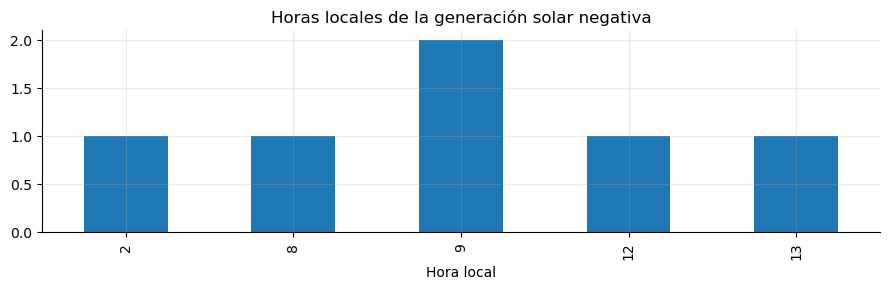

[C.2] fenómeno físico: Generación solar/termosolar negativa de noche


In [67]:
SOLTER = pick(df, "esios_gen_ree_gsolter_mw")
negs = [c for c in (SOLTER, SOL_REE) if c and (df[c] < 0).any()]

if not negs:
    print("Sin valores negativos de generación solar en este parquet.")
else:
    for c in negs:
        sub = df[df[c] < 0]
        nocturnas = sub["hora"].isin(list(range(0, 8)) + list(range(19, 24))).mean() * 100
        print(f"{c}: {len(sub)} filas negativas, mínimo {df[c].min():.2f} MW, "
              f"{nocturnas:.0f}% en horas nocturnas")
    sub = df[df[negs[0]] < 0]
    ax = sub["hora"].value_counts().sort_index().plot(kind="bar", figsize=(9, 3),
        title="Horas locales de la generación solar negativa")
    ax.set_xlabel("Hora local"); plt.tight_layout(); plt.show()
    anotar("C.2", "Generación solar/termosolar negativa de noche", "fenómeno físico",
           "Consumo auxiliar de plantas termosolares. NO corregir.")

---
## D · Cobertura temporal y bordes de cambio de hora

**Contexto.** El día de 23 horas de marzo y el de 25 de octubre son donde un `groupby` por fecha
local mal hecho se rompe en silencio. El día largo tiene **dos horas 02:00**, y hay que agregarlas
con `groupby().mean()`; un `pivot_table(aggfunc="first")` descarta la segunda sin avisar.

**Consecuencia.** Si los días con ≠24 horas coinciden exactamente con los cambios de horario,
`date_local`/`hour_local` reflejan el DST real sin duplicar ni perder filas, y se puede confiar
en cualquier agregación diaria del resto del EDA.

In [68]:
horas_dia = df.groupby("date_local").size()
atipicos = horas_dia[horas_dia != 24]
print(f"Días con != 24 horas locales: {len(atipicos)}")
if len(atipicos):
    display(atipicos.rename("horas").to_frame())
    print("\nEsperado: uno de 23 h y uno de 25 h por año (cambios de horario), más los "
          "días de borde del rango. Cualquier otro es un hueco de datos.")
    print(f"\nDías de 23 h: {(atipicos == 23).sum()} · de 25 h: {(atipicos == 25).sum()}")

completo = pd.date_range(df["ts_utc"].min(), df["ts_utc"].max(), freq="h", tz="UTC")
faltan = completo.difference(df["ts_utc"])
print(f"\nHoras ausentes del calendario UTC: {len(faltan)}")

Días con != 24 horas locales: 13


,horas
date_local,
2020-03-29,23
2020-10-25,25
2021-03-28,23
2021-10-31,25
2022-03-27,23
2022-10-30,25
2023-03-26,23
2023-10-29,25
2024-03-31,23



Esperado: uno de 23 h y uno de 25 h por año (cambios de horario), más los días de borde del rango. Cualquier otro es un hueco de datos.

Días de 23 h: 7 · de 25 h: 6

Horas ausentes del calendario UTC: 0


---
## E · Consistencia cruzada entre fuentes

**Contexto.** Cuando dos fuentes miden lo mismo, o coinciden y son intercambiables, o no
coinciden y hay que elegir con un motivo. Los dos casos que siguen tienen respuestas opuestas, y
por eso conviene mirarlos juntos.

### E.1 · Eólica: ¿son intercambiables ESIOS y ENTSO-E?

La matriz del equipo marca `ree_gwind_mw` como "coincide con ENTSO-E (±0,2 %)" y elige
`entsoe_wind_mw` **por coherencia** con el resto de la matriz — a diferencia del gas o la solar,
aquí no habría un motivo físico para preferir una fuente.

In [69]:
W_ENT = pick(df, "entsoe_wind_mw")
W_REE = pick(df, "esios_gen_ree_gwind_mw")

if not (W_ENT and W_REE):
    print("OMITIDO --", {"entsoe": W_ENT, "ree": W_REE})
else:
    d = df[[W_ENT, W_REE]].dropna()
    print(f"Correlación: {d[W_ENT].corr(d[W_REE]):.5f}")
    dif_pct = (d[W_REE] - d[W_ENT]) / d[W_ENT].replace(0, np.nan) * 100
    print(f"Diferencia % media: {dif_pct.mean():.3f}")
    print(f"Diferencia % mediana: {dif_pct.median():.3f}")
    print(f"Diferencia % máxima absoluta: {dif_pct.abs().max():,.1f}")
    print("\nLa máxima suele ser enorme por dividir entre un denominador diminuto (horas de "
          "viento casi nulo). Por eso la MEDIANA es la métrica honesta aquí, no el máximo.")
    display(d.describe().round(1))

Correlación: 0.99960
Diferencia % media: 0.057
Diferencia % mediana: 0.005
Diferencia % máxima absoluta: 317.7

La máxima suele ser enorme por dividir entre un denominador diminuto (horas de viento casi nulo). Por eso la MEDIANA es la métrica honesta aquí, no el máximo.


,entsoe_wind_mw,esios_gen_ree_gwind_mw
count,58283.0,58283.0
mean,6546.1,6547.4
std,3888.0,3888.0
min,181.0,182.2
25%,3454.0,3457.0
50%,5802.0,5804.0
75%,9002.0,9006.1
max,20718.0,20699.2


### E.2 · Hidráulica: aquí sí hay motivo para elegir

**Contexto documentado.** `ree_ghidro_mw` (ESIOS, indicador 546) mezclaría hidráulica de
generación con consumo de bombeo en una sola columna, llegando a valores muy negativos al
mediodía. ENTSO-E separa ambos conceptos en columnas propias.

**Aviso de la corrida anterior:** este bloque dio una correlación de **−0,004** y **cero valores
negativos**, con mínimo en 105,76 MW. Eso *no* confirma lo documentado. Y no puede achacarse a
un desalineamiento del parquet de ESIOS, porque E.1 con el mismo cruce da 0,9996. Si vuelve a
salir así, hay que verificar el mapeo de la columna contra el indicador 546 antes de escribir
nada en la memoria.

Correlación ree_ghidro vs suma ENTSO-E: 0.86645
Mínimo de ree_ghidro: -3,710.00 MW
Filas negativas: 8,831


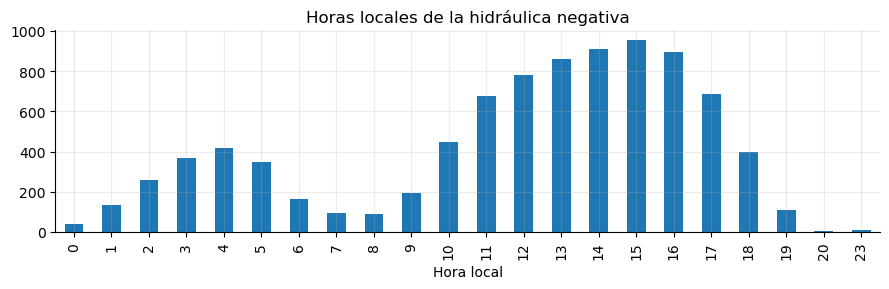

Concentradas al mediodía = pico de bombeo: confirma la mezcla de conceptos.
[E.2] confirmado: ree_ghidro mezcla generación y bombeo


In [70]:
H_RIVER = pick(df, "entsoe_hydro_run_river_mw")
H_RES = pick(df, "entsoe_hydro_reservoir_mw")
H_REE = pick(df, "esios_gen_ree_ghidro_mw")

if not all([H_RIVER, H_RES, H_REE]):
    print("OMITIDO --", {"river": H_RIVER, "reservoir": H_RES, "ree": H_REE})
else:
    d = df[["hora", H_RIVER, H_RES, H_REE]].dropna().copy()
    d["suma_entsoe"] = d[H_RIVER] + d[H_RES]
    r = d[H_REE].corr(d["suma_entsoe"])
    negativos = (d[H_REE] < 0).sum()

    print(f"Correlación ree_ghidro vs suma ENTSO-E: {r:.5f}")
    print(f"Mínimo de ree_ghidro: {d[H_REE].min():,.2f} MW")
    print(f"Filas negativas: {negativos:,}")

    if negativos:
        ax = d[d[H_REE] < 0]["hora"].value_counts().sort_index().plot(
            kind="bar", figsize=(9, 3), title="Horas locales de la hidráulica negativa")
        ax.set_xlabel("Hora local"); plt.tight_layout(); plt.show()
        print("Concentradas al mediodía = pico de bombeo: confirma la mezcla de conceptos.")
        anotar("E.2", "ree_ghidro mezcla generación y bombeo", "confirmado",
               "Usar entsoe_hydro_run_river + entsoe_hydro_reservoir.")
    else:
        print("\nNO confirma lo documentado: sin negativos y correlación cercana a cero.")
        print("Verificar el mapeo de esios_gen_ree_ghidro_mw contra el indicador 546 de ESIOS "
              "antes de dar E.2 por cerrado en ningún sentido.")
        anotar("E.2", "ree_ghidro no se comporta como documenta D-0x", "ABIERTO",
               "Correlación ~0 y sin negativos. Revisar el mapeo del indicador antes de "
               "escribir nada en la memoria.")

---
## F · Discontinuidades de ingesta

**Contexto.** Los dos hallazgos de este bloque no se ven en un perfil de nulos, porque **uno de
ellos no deja nulos**. Son el tipo de problema que aparece en la defensa si no lo detectas tú.

### F.1 · ERA5: un mes entero sin ráfaga

Los nulos de `wind_gust10_mean` que quedaron sin explicar en B.2 son, verificado sobre la tabla
completa, **exactamente junio de 2026**: del día 1 a las 00:00 al 30 a las 21:00, bloque continuo
de 240 pasos de 3 h, con el resto de variables completas en ese mismo mes.

Un mes entero, una sola variable, sin excepciones: es un fallo de una ejecución concreta, no un
patrón. **Reparable reingiriendo el mes.**

In [71]:
if GUST:
    nulos_mes = df.groupby("mes_p")[GUST].apply(lambda s: s.isna().sum())
    estructurales = df.groupby("mes_p")[W10].apply(lambda s: s.isna().sum()) if W10 else 0
    extra = (nulos_mes - estructurales) if W10 is not None else nulos_mes
    con_hueco = extra[extra > 0]
    print(f"Meses con nulos de ráfaga por encima de lo estructural: {len(con_hueco)}")
    if len(con_hueco):
        display(con_hueco.rename("nulos extra").to_frame())
        anotar("F.1", "era5_wind_gust10_mean sin dato en un mes completo", "identificado",
               "Fallo de una ejecución concreta. Reingerir ese mes.")

Meses con nulos de ráfaga por encima de lo estructural: 1


,nulos extra
mes_p,
2026-06,240


[F.1] identificado: era5_wind_gust10_mean sin dato en un mes completo


### F.2 · ERA5: cambio de entorno de ingesta en enero de 2025

**Contexto.** El campo `tensor_path` de la tabla original apunta a `/home/ubuntu/scripts/...`
hasta diciembre de 2024 y a `\data\era5_tensors\` (ruta de Windows) desde enero de 2025, sin
excepciones: **20 meses seguidos**. El pipeline cambió de máquina y sigue así.

**Por qué importa más que F.1.** Diecinueve de esos veinte meses están completos, así que el
cambio no causa nulos. Pero si cambió la malla, el recorte geográfico o la versión del
agregador, las series de 2025-2026 podrían tener un **sesgo** invisible en el perfil de nulos —
y ese tramo es justo el período de test.

Es el mismo tipo de discontinuidad que D-03 con el autoconsumo de REE. La diferencia es que
aquélla está documentada y ésta no lo estaba.

**Cómo se comprueba.** `msl_mean` (presión a nivel del mar) es la variable más estable del
conjunto: su media climatológica apenas cambia de un año a otro. Se compara **mes contra mes del
año** a ambos lados del corte, para que la estacionalidad no contamine el contraste.

In [72]:
CORTE = pd.Timestamp("2025-01-01", tz="UTC")
if era5:
    e = df[["ts_utc", "mes_p"] + era5].dropna(how="all", subset=era5).copy()
    e["entorno"] = np.where(e["ts_utc"] >= CORTE, "desde 2025", "hasta 2024")
    e["mes"] = e["mes_p"].dt.month

    filas = []
    for c in era5:
        pm = e.pivot_table(index="mes", columns="entorno", values=c, aggfunc="mean")
        if pm.shape[1] < 2:
            continue
        dif = pm["desde 2025"] - pm["hasta 2024"]
        filas.append({"variable": c, "dif. media": dif.mean(),
                      "dif. % sobre la media": dif.mean() / e[c].mean() * 100,
                      "dif. máx en un mes": dif.abs().max()})
    if filas:
        r = pd.DataFrame(filas).set_index("variable")
        display(r.reindex(r["dif. % sobre la media"].abs().sort_values(ascending=False).index).round(4))
        print("Diferencias por debajo de ~0,5% son ruido climático entre años distintos.")
        print("Una diferencia sistemática y del MISMO SIGNO en todas las variables sería la "
              "firma de un cambio de agregador, no del tiempo.")

,dif. media,dif. % sobre la media,dif. máx en un mes
variable,,,
era5_tp_mean,0.0124,16.5653,0.0729
era5_tcc_mean,0.0062,1.3183,0.1174
era5_wind100_mean,0.0501,0.9360,1.3570
era5_wind10_mean,0.0344,0.8900,0.9098
era5_wind_gust10_mean,0.0466,0.6610,1.6227
era5_ssrd_mean,0.5232,0.2641,17.9329
era5_t2m_mean,0.3335,0.1152,2.2706
era5_msl_mean,-105.9880,-0.1042,658.5855
era5_d2m_mean,0.2933,0.1035,1.4105


Diferencias por debajo de ~0,5% son ruido climático entre años distintos.
Una diferencia sistemática y del MISMO SIGNO en todas las variables sería la firma de un cambio de agregador, no del tiempo.


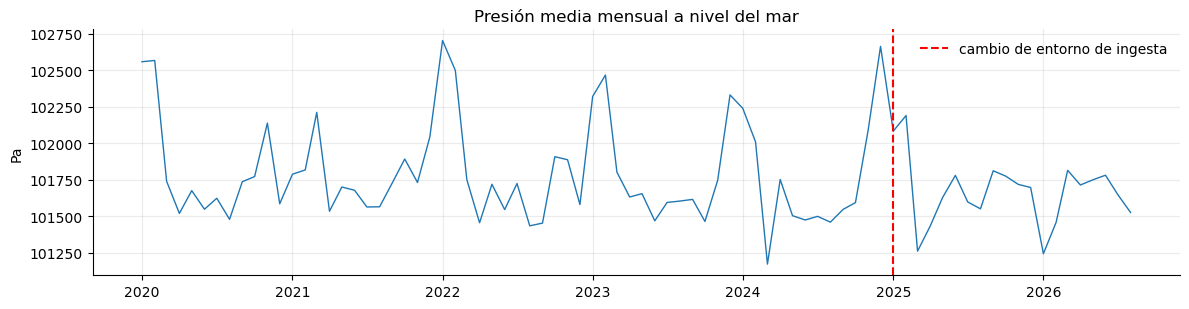

Un escalón visible en la línea roja sería evidencia de cambio metodológico. Oscilación sin salto = meteorología normal.


In [73]:
MSL = pick(df, "era5_msl_mean")
if MSL:
    m = df.groupby("mes_p")[MSL].mean().dropna()
    fig, ax = plt.subplots(figsize=(12, 3.2))
    ax.plot(m.index.to_timestamp(), m.values, lw=1)
    ax.axvline(CORTE.tz_localize(None), color="red", ls="--",
               label="cambio de entorno de ingesta")
    ax.set_ylabel("Pa"); ax.set_title("Presión media mensual a nivel del mar")
    ax.legend(frameon=False); plt.tight_layout(); plt.show()
    print("Un escalón visible en la línea roja sería evidencia de cambio metodológico. "
           "Oscilación sin salto = meteorología normal.")

---
## G · Cierre

In [74]:
if HALLAZGOS:
    display(pd.DataFrame(HALLAZGOS).set_index("código"))
else:
    print("Ningún hallazgo registrado: revisar si los bloques corrieron.")

,hallazgo,estado,consecuencia
código,,,
D-02,"El B04 de ENTSO-E mezcla CCGT y cogeneración, ...",confirmado,Usar ESIOS con las dos columnas separadas. ent...
D-03,Autoconsumo dentro de las series de ESIOS desd...,confirmado,No usar ree_load ni ree_gsolar_mw directos. FV...
D-04,6 columnas de capacidad con varianza cero,confirmado,Correctas pero inútiles como feature. Se traen...
B.1,pumping_gen usa NULL y pumping_cons usa 0 para...,confirmado,En el maestro: fillna(0) sobre pumping_gen_mw ...
C.1,9 horas de entsoe_load en cero espurio,confirmado,Fallo de ingesta documentado en pipeline_log. ...
C.2,Generación solar/termosolar negativa de noche,fenómeno físico,Consumo auxiliar de plantas termosolares. NO c...
E.2,ree_ghidro mezcla generación y bombeo,confirmado,Usar entsoe_hydro_run_river + entsoe_hydro_res...
F.1,era5_wind_gust10_mean sin dato en un mes completo,identificado,Fallo de una ejecución concreta. Reingerir ese...


In [75]:
for l in [
    "QUÉ SALE DE AQUÍ",
    "=" * 62,
    "",
    "Decisiones confirmadas con evidencia propia (van a docs/decisiones_datos.md como",
    "validación independiente, no reemplazan a las del equipo: las respaldan):",
    "  D-02  el B04 de ENTSO-E mezcla CCGT y cogeneración, con offset no estable",
    "  D-03  el autoconsumo entra por los dos lados del balance desde dic-2025",
    "  D-04  columnas de capacidad con varianza cero",
    "",
    "Acciones concretas sobre el dataset de modelado:",
    "  B.1  fillna(0) sobre pumping_gen_mw ANTES de agregar, sólo sobre esa columna",
    "  C.1  reparar los ceros de entsoe_load con entsoe_load_inter.actual_load_mw",
    "  B.2  no interpolar linealmente wind_gust10_mean ni tp_mean: son variables de pico",
    "",
    "Abierto, y hay que resolverlo o declararlo:",
    "  E.2  ree_ghidro no se comporta como documenta la decisión: revisar el mapeo",
    "  F.1  reingerir el mes de ERA5 sin ráfaga",
    "  F.2  verificar el cambio de entorno de ene-2025 antes de usar era5 en el test",
    "",
    "Fuera de alcance de este notebook, y por eso existen los siguientes:",
    "  el target y su estructura            -> 03_eda_vitaminado_v2",
    "  el balance del sistema               -> 04_eda_balance_sistema_v2",
    "  interconexiones y formación de precio -> 05_eda_interconexiones_precio_v2",
]:
    print(l)

QUÉ SALE DE AQUÍ

Decisiones confirmadas con evidencia propia (van a docs/decisiones_datos.md como
validación independiente, no reemplazan a las del equipo: las respaldan):
  D-02  el B04 de ENTSO-E mezcla CCGT y cogeneración, con offset no estable
  D-03  el autoconsumo entra por los dos lados del balance desde dic-2025
  D-04  columnas de capacidad con varianza cero

Acciones concretas sobre el dataset de modelado:
  B.1  fillna(0) sobre pumping_gen_mw ANTES de agregar, sólo sobre esa columna
  C.1  reparar los ceros de entsoe_load con entsoe_load_inter.actual_load_mw
  B.2  no interpolar linealmente wind_gust10_mean ni tp_mean: son variables de pico

Abierto, y hay que resolverlo o declararlo:
  E.2  ree_ghidro no se comporta como documenta la decisión: revisar el mapeo
  F.1  reingerir el mes de ERA5 sin ráfaga
  F.2  verificar el cambio de entorno de ene-2025 antes de usar era5 en el test

Fuera de alcance de este notebook, y por eso existen los siguientes:
  el target y su estruc